# DeepLense GSoC 2026 — Test I: Multi-Class Classification

Classify strong lensing images into three classes: `no_sub`, `subhalo`, `vortex`.

**Approach:** Fine-tuned EfficientNet-B0. Two-phase training — frozen backbone warmup, then full fine-tune. Augmentation restricted to flips and 90° rotations (lensing images have no preferred orientation, so these are physically meaningful).

In [8]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

ZIP_PATH = '/content/drive/MyDrive/Colab Notebooks/GoSC26/ML4DQM/dataset.zip'
EXTRACT  = '/content/drive/MyDrive/Colab Notebooks/GoSC26/ML4DQM/dataset'

if not os.path.exists(EXTRACT):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT)
    print('Extracted.')
else:
    print('Already extracted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted.


In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import matplotlib
# matplotlib.rcParams['figure.dpi'] = 110

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## Dataset

In [14]:
for root, dirs, files in os.walk(EXTRACT):
    level = root.replace(EXTRACT, '').count(os.sep)
    print('  ' * level + os.path.basename(root) + '/')
    if level > 3:
        break

dataset/
  dataset/
    train/
      vort/
      no/
      sphere/
    val/
      vort/
      no/
      sphere/
  __MACOSX/
    dataset/
      train/
      val/


In [21]:
CLASS_NAMES  = ['no', 'sphere', 'vort']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
DISPLAY_NAMES = {'no': 'no_sub', 'sphere': 'subhalo', 'vort': 'vortex'} # to fit description

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]


class LensingDataset(Dataset):
    def __init__(self, root):
        self.samples = []
        for cls, idx in CLASS_TO_IDX.items():
            d = os.path.join(root, cls)
            for f in sorted(os.listdir(d)):
                if f.endswith('.npy'):
                    self.samples.append((os.path.join(d, f), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.load(path).astype(np.float32)
        if img.ndim == 3:
            img = img.squeeze(0)
        img_t = torch.from_numpy(img).unsqueeze(0).repeat(3, 1, 1)
        return img_t, label


class WithTransform(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label


train_tf = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomApply([T.RandomRotation((90, 90))], p=0.5),
    T.Resize((224, 224)),
    T.Normalize(MEAN, STD),
])

val_tf = T.Compose([
    T.Resize((224, 224)),
    T.Normalize(MEAN, STD),
])

DATA_ROOT = EXTRACT
for root, dirs, files in os.walk(EXTRACT):
    if 'train' in dirs and 'val' in dirs:
        DATA_ROOT = root
        break
print('DATA_ROOT:', DATA_ROOT)

train_set = WithTransform(LensingDataset(os.path.join(DATA_ROOT, 'train')), train_tf)
val_set   = WithTransform(LensingDataset(os.path.join(DATA_ROOT, 'val')),   val_tf)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2)

print(f'Train: {len(train_set)}  Val: {len(val_set)}')
for c, i in CLASS_TO_IDX.items():
    n = sum(1 for _, l in train_set.subset.samples if l == i)
    print(f'  {c}: {n}')

DATA_ROOT: /content/drive/MyDrive/Colab Notebooks/GoSC26/ML4DQM/dataset/dataset
Train: 30000  Val: 7500
  no: 10000
  sphere: 10000
  vort: 10000


In [11]:
print(os.listdir(DATA_ROOT))

['.DS_Store', 'train', 'val']


## Model

In [16]:
class LensingClassifier(nn.Module):
    def __init__(self, num_classes=3, freeze_backbone=False):
        super().__init__()
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.backbone = base.features
        self.pool     = base.avgpool
        self.dropout  = nn.Dropout(0.3)
        self.head     = nn.Linear(1280, num_classes)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def unfreeze(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x).flatten(1)
        return self.head(self.dropout(x))


model = LensingClassifier(freeze_backbone=True).to(DEVICE)
print('Trainable params:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 165MB/s]


Trainable params: 3843


## Training

Phase 1 (5 epochs): head only, backbone frozen.  
Phase 2 (25 epochs): full fine-tune, cosine LR decay.

In [17]:
WARMUP   = 5
FINETUNE = 25
TOTAL    = WARMUP + FINETUNE

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=WARMUP)

history = {'tl': [], 'vl': [], 'ta': [], 'va': []}

for epoch in range(1, TOTAL + 1):
    if epoch == WARMUP + 1:
        print('--- unfreezing backbone ---')
        model.unfreeze()
        optimizer = optim.Adam(model.parameters(), lr=3e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE)

    for phase, loader, train in [('train', train_loader, True), ('val', val_loader, False)]:
        model.train(train)
        loss_sum, correct, total = 0., 0, 0
        with torch.set_grad_enabled(train):
            for imgs, labels in loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = model(imgs)
                loss   = criterion(logits, labels)
                if train:
                    optimizer.zero_grad(); loss.backward(); optimizer.step()
                loss_sum += loss.item() * len(labels)
                correct  += (logits.argmax(1) == labels).sum().item()
                total    += len(labels)
        key = 't' if phase == 'train' else 'v'
        history[key + 'l'].append(loss_sum / total)
        history[key + 'a'].append(correct / total)

    scheduler.step()
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d}/{TOTAL}  '
              f'train loss {history["tl"][-1]:.4f} acc {history["ta"][-1]:.4f}  '
              f'val loss {history["vl"][-1]:.4f} acc {history["va"][-1]:.4f}')

torch.save(model.state_dict(), 'lensing_efficientnet_b0.pt')
print('Saved.')

Epoch  1/30  train loss 1.1135 acc 0.3607  val loss 1.1029 acc 0.3655
Epoch  5/30  train loss 1.0922 acc 0.3818  val loss 1.0814 acc 0.3912
--- unfreezing backbone ---
Epoch 10/30  train loss 0.2799 acc 0.8967  val loss 0.2688 acc 0.9013
Epoch 15/30  train loss 0.1788 acc 0.9355  val loss 0.1770 acc 0.9360
Epoch 20/30  train loss 0.1253 acc 0.9562  val loss 0.1492 acc 0.9483
Epoch 25/30  train loss 0.0886 acc 0.9691  val loss 0.1243 acc 0.9611
Epoch 30/30  train loss 0.0727 acc 0.9757  val loss 0.1224 acc 0.9619
Saved.


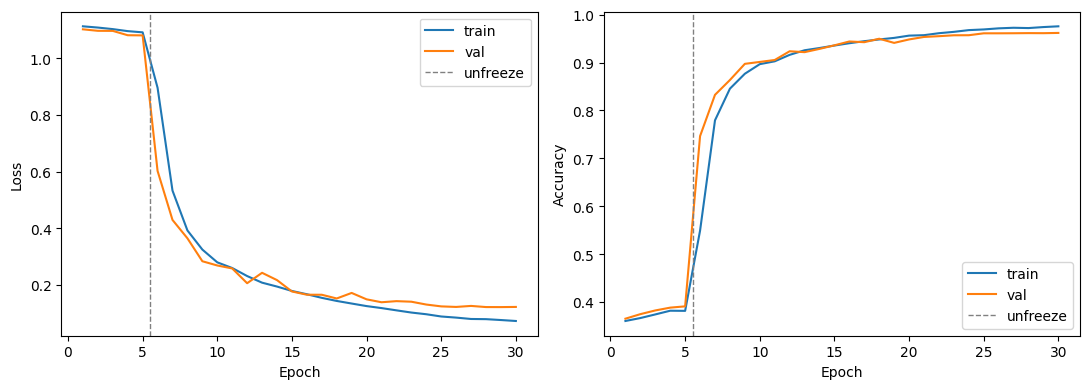

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ep = range(1, TOTAL + 1)

ax1.plot(ep, history['tl'], label='train')
ax1.plot(ep, history['vl'], label='val')
ax1.axvline(WARMUP + 0.5, color='gray', ls='--', lw=1, label='unfreeze')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()

ax2.plot(ep, history['ta'], label='train')
ax2.plot(ep, history['va'], label='val')
ax2.axvline(WARMUP + 0.5, color='gray', ls='--', lw=1, label='unfreeze')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight')
plt.show()

## Evaluation

In [23]:
for cls, a in aucs.items():
    print(f'  {DISPLAY_NAMES[cls]}: {a:.4f}')

  no_sub: 0.9946
  subhalo: 0.9909
  vortex: 0.9978


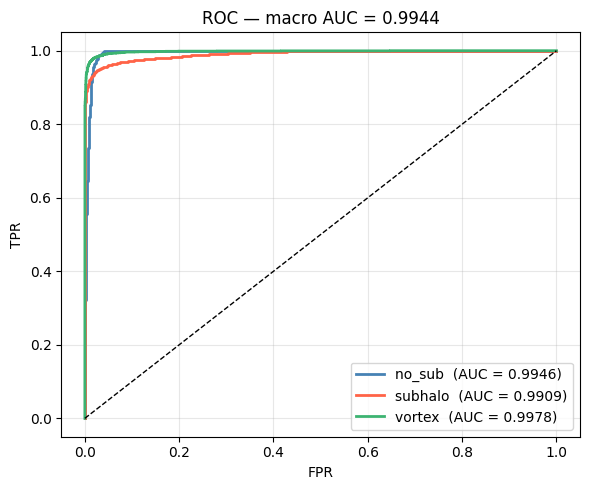

AUC per class:
  no: 0.9946
  sphere: 0.9909
  vort: 0.9978
  macro: 0.9944


In [24]:
model.eval()
probs_all, labels_all = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        p = torch.softmax(model(imgs.to(DEVICE)), dim=1).cpu().numpy()
        probs_all.append(p)
        labels_all.append(labels.numpy())

probs_all  = np.concatenate(probs_all)
labels_all = np.concatenate(labels_all)
labels_bin = label_binarize(labels_all, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['steelblue', 'tomato', 'mediumseagreen']
aucs = {}

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], probs_all[:, i])
    a = auc(fpr, tpr)
    aucs[cls] = a
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{DISPLAY_NAMES[cls]}  (AUC = {a:.4f})')

macro = np.mean(list(aucs.values()))
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC — macro AUC = {macro:.4f}')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

print('AUC per class:')
for cls, a in aucs.items():
    print(f'  {cls}: {a:.4f}')
print(f'  macro: {macro:.4f}')

## Sample predictions

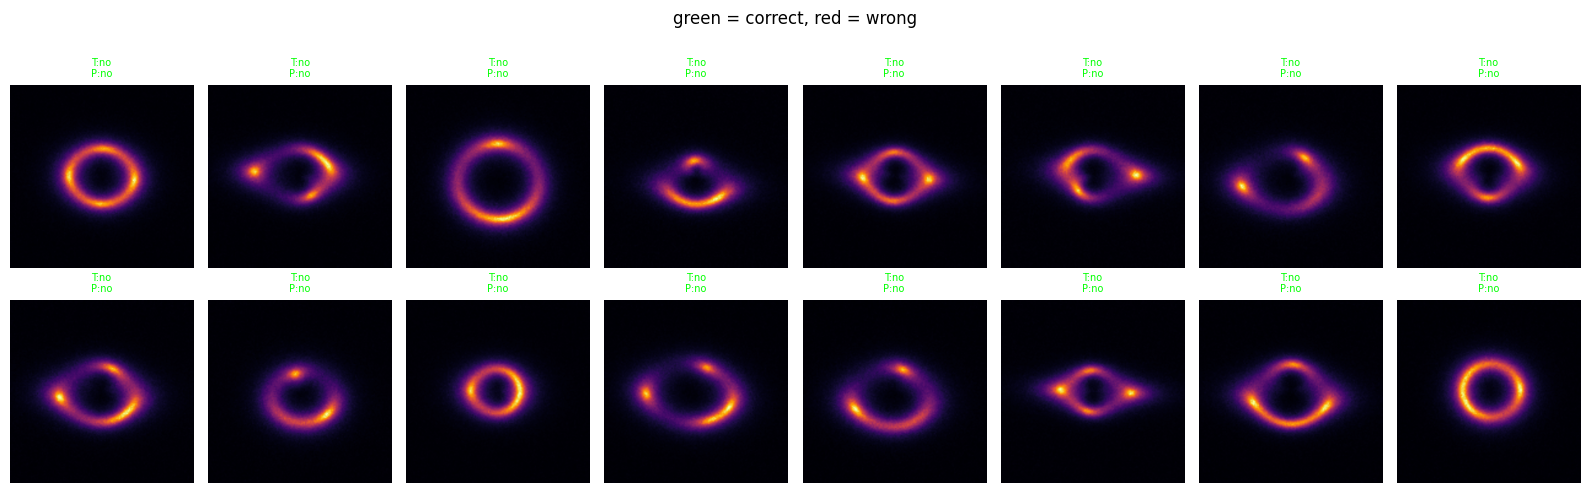

In [20]:
model.eval()
imgs, labels = next(iter(val_loader))
with torch.no_grad():
    preds = model(imgs.to(DEVICE)).argmax(1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs): break
    img = imgs[i, 0].numpy() * STD[0] + MEAN[0]
    ax.imshow(img, cmap='inferno', origin='lower')
    t = CLASS_NAMES[labels[i].item()]
    p = CLASS_NAMES[preds[i].item()]
    ax.set_title(f'T:{t}\nP:{p}', fontsize=7,
                 color='lime' if t == p else 'red')
    ax.axis('off')
plt.suptitle('green = correct, red = wrong', y=1.01)
plt.tight_layout()
plt.savefig('sample_predictions.png', bbox_inches='tight')
plt.show()